# Pipeline visualization — NYX baryon density

Mirrors the schematic: **Original X** → **Decompressed X'** (SZ3) → residual `R = X - X'`, split by the model's **three frequency heads** into **low / mid / high** bands, then the **combined residual** (which the user adds back: X̂ = X' + R̂).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.append("/home/sam/Data_Compression/SZ3/tools/pysz")
sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")
import torch
from pysz import SZ
from bg_sampling import _gaussian_low_mid_high_split_t   # the model's exact Gaussian band split

SZ3_LIB = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
NYX_DIR = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
SHAPE   = (512, 512, 512)
FIELD   = "baryon_density"
REL     = 1e-5                     # SZ3 rel error bound (looser -> more visible residual)
SLICE_AXIS, SLICE_IDX = 0, 256     # which 2-D slice to visualize
SIGMA_LOW, SIGMA_MID  = 0.08, 0.18 # SAME bands as the BG model (cfg.bg_sigma_low / bg_sigma_mid)

# original -> SZ3 compress -> decompress  (the pipeline's first two stages)
sz = SZ(SZ3_LIB)
X  = np.fromfile(NYX_DIR + FIELD + ".f32", dtype=np.float32).reshape(SHAPE)
blob, cr = sz.compress(X, 1, 0, float(REL), 0)
Xp = sz.decompress(blob, SHAPE, np.float32)
print(f"{FIELD} | rel={REL:.0e} | SZ3 CR={float(cr):.1f}")

x  = np.take(X,  SLICE_IDX, axis=SLICE_AXIS).astype(np.float32)   # original slice
xp = np.take(Xp, SLICE_IDX, axis=SLICE_AXIS).astype(np.float32)   # decompressed slice
R  = x - xp                                                       # SZ3 residual (model's target)

# split the residual into the model's three frequency bands (what each head predicts)
_rt = torch.from_numpy(np.ascontiguousarray(R))[None, None]
R_low, R_mid, R_high = (t[0, 0].numpy() for t in
                        _gaussian_low_mid_high_split_t(_rt, SIGMA_LOW, SIGMA_MID))
R_comb = R_low + R_mid + R_high            # combined residual == R (masks sum to 1)
print("max|R_comb - R| =", float(np.abs(R_comb - R).max()), "(bands reconstruct R)")


baryon_density | rel=1e-05 | SZ3 CR=439.6
max|R_comb - R| = 3.5762786865234375e-07 (bands reconstruct R)


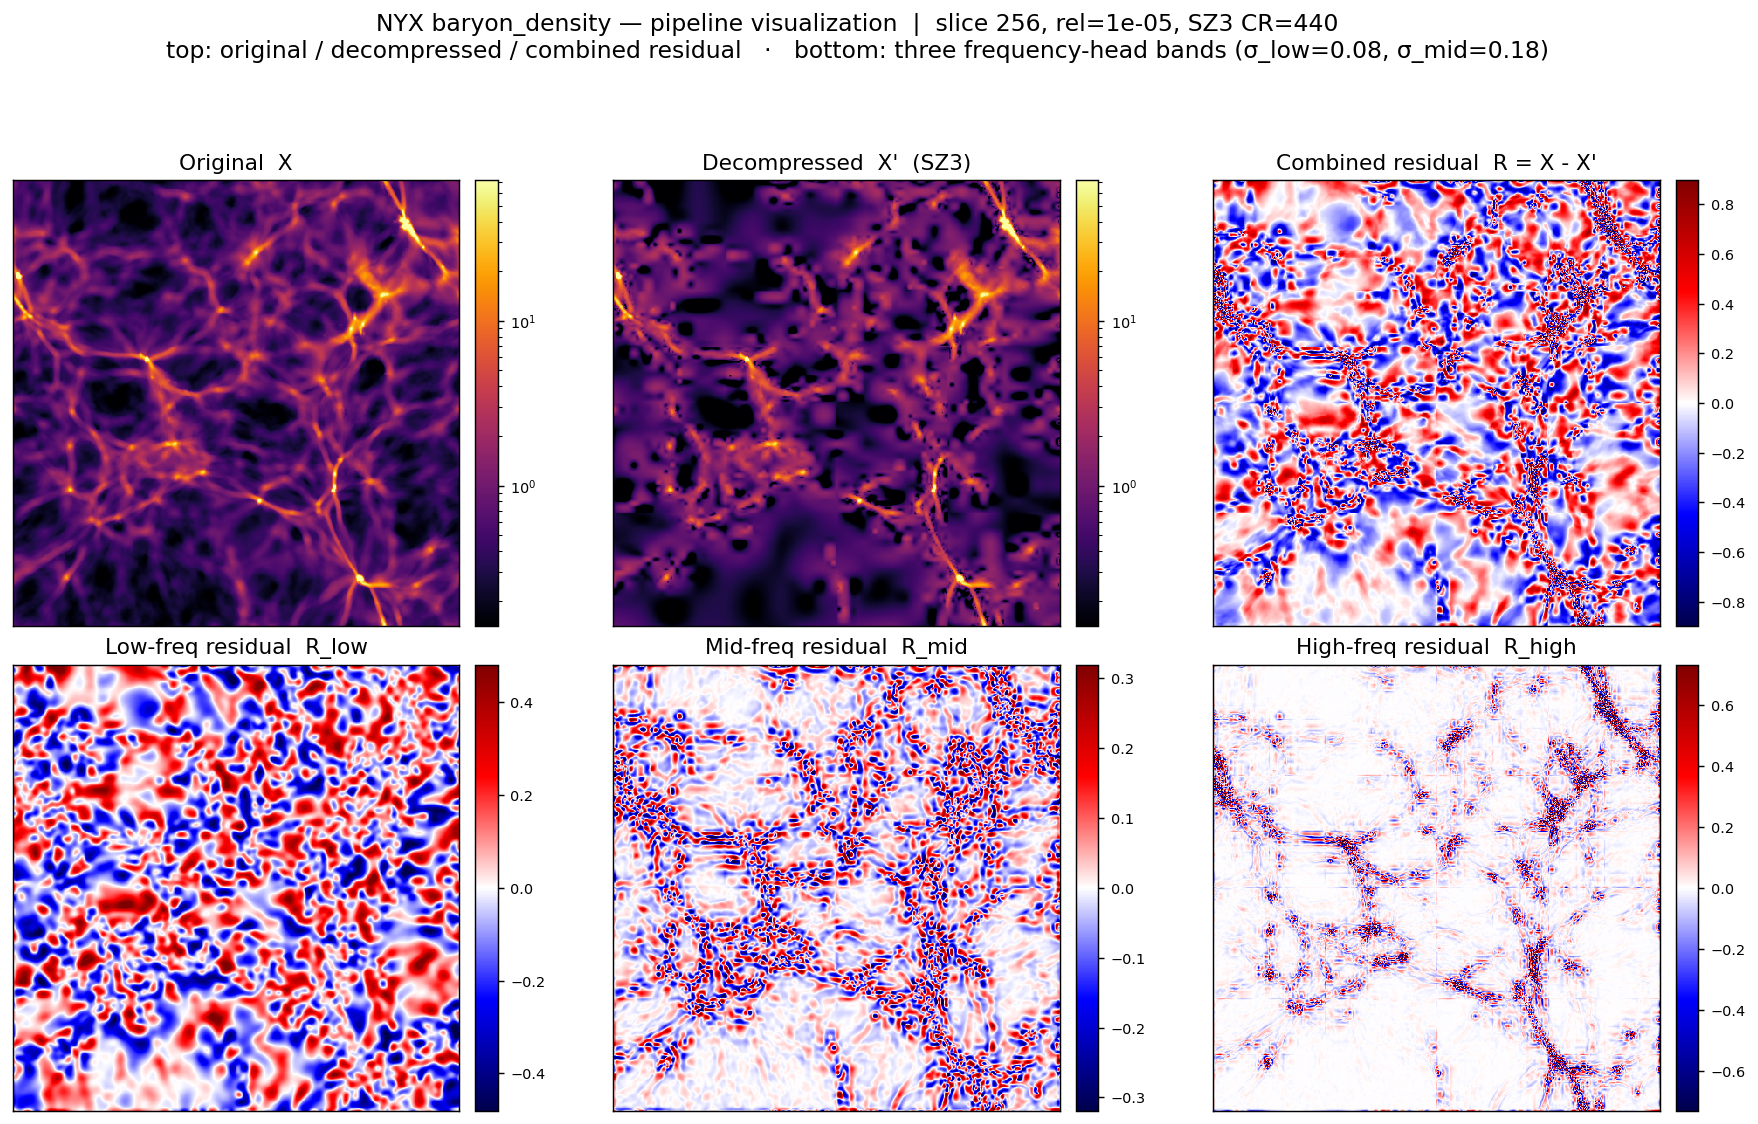

Saved: visualization.svg / visualization.png


In [2]:
def _sym(a, p=99.5):
    m = float(np.percentile(np.abs(a), p)) or 1e-12
    return dict(cmap="seismic", vmin=-m, vmax=m)

def _show(ax, img, title, **kw):
    im = ax.imshow(img, origin="lower", interpolation="nearest", **kw)
    ax.set_title(title, fontsize=12, pad=6); ax.set_xticks([]); ax.set_yticks([])
    cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.03); cb.ax.tick_params(labelsize=8)

# shared log scale for original vs decompressed (so they're directly comparable)
_pos = x[x > 0]
ln = LogNorm(vmin=max(np.percentile(_pos, 1), 1e-6), vmax=np.percentile(x, 99.9), clip=True)

fig, ax = plt.subplots(2, 3, figsize=(14, 8.6), dpi=130)
_show(ax[0, 0], x,      "Original  X",                 cmap="inferno", norm=ln)
_show(ax[0, 1], xp,     "Decompressed  X'  (SZ3)",     cmap="inferno", norm=ln)
_show(ax[0, 2], R_comb, "Combined residual  R = X - X'", **_sym(R_comb))
_show(ax[1, 0], R_low,  "Low-freq residual  R_low",    **_sym(R_low))
_show(ax[1, 1], R_mid,  "Mid-freq residual  R_mid",    **_sym(R_mid))
_show(ax[1, 2], R_high, "High-freq residual  R_high",  **_sym(R_high))

fig.suptitle(f"NYX {FIELD} — pipeline visualization  |  slice {SLICE_IDX}, rel={REL:.0e}, SZ3 CR={float(cr):.0f}\n"
             f"top: original / decompressed / combined residual   ·   bottom: three frequency-head bands "
             f"(σ_low={SIGMA_LOW}, σ_mid={SIGMA_MID})",
             fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("visualization.svg", bbox_inches="tight")
plt.savefig("visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visualization.svg / visualization.png")


In [3]:
# ── save each panel as its own PDF (vector, for paper sub-figures) ─────────────
from pathlib import Path
PANEL_DIR    = Path("panels"); PANEL_DIR.mkdir(exist_ok=True)
PANEL_TITLES = False     # True -> bake the title into each PDF; False -> bare image + colorbar

def _sym(a, p=99.5):
    m = float(np.percentile(np.abs(a), p)) or 1e-12
    return dict(cmap="seismic", vmin=-m, vmax=m)
_pos = x[x > 0]
ln = LogNorm(vmin=max(np.percentile(_pos, 1), 1e-6), vmax=np.percentile(x, 99.9), clip=True)

panels = [
    ("01_original",          x,      dict(cmap="inferno", norm=ln), "Original  X"),
    ("02_decompressed",      xp,     dict(cmap="inferno", norm=ln), "Decompressed  X'  (SZ3)"),
    ("03_combined_residual", R_comb, _sym(R_comb),                  "Combined residual  R = X - X'"),
    ("04_low_residual",      R_low,  _sym(R_low),                   "Low-freq residual  R_low"),
    ("05_mid_residual",      R_mid,  _sym(R_mid),                   "Mid-freq residual  R_mid"),
    ("06_high_residual",     R_high, _sym(R_high),                  "High-freq residual  R_high"),
]
for name, img, kw, ttl in panels:
    f, a = plt.subplots(figsize=(4.6, 4.2), dpi=130)
    im = a.imshow(img, origin="lower", interpolation="nearest", **kw)
    a.set_xticks([]); a.set_yticks([])
    if PANEL_TITLES:
        a.set_title(ttl, fontsize=12, pad=6)
    cb = f.colorbar(im, ax=a, fraction=0.046, pad=0.03); cb.ax.tick_params(labelsize=8)
    f.savefig(PANEL_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.close(f)
    print("saved", (PANEL_DIR / f"{name}.pdf"))
print("done -> 6 panel PDFs in", PANEL_DIR.resolve())


saved panels/01_original.pdf
saved panels/02_decompressed.pdf
saved panels/03_combined_residual.pdf
saved panels/04_low_residual.pdf
saved panels/05_mid_residual.pdf
saved panels/06_high_residual.pdf
done -> 6 panel PDFs in /home/sam/Halo_Finder/Final_design/figures/panels
